# Notebook 02: Transformer Architecture

**Time:** 35 minutes  
**Prerequisites:** Notebook 01 complete  
**Goal:** Build deep intuition for how Transformers work by *implementing* the key components

This notebook will:
1. Implement scaled dot-product attention from scratch in NumPy
2. Visualise multi-head attention with BertViz
3. Plot sinusoidal positional encoding
4. Run a PyTorch MiniTransformerBlock forward pass
5. Ask Claude to explain its own architecture

> 💡 **Why does this matter?** Every LLM you use — Claude, GPT-4, Llama — is built on the architecture you'll understand in this notebook.

## Setup

In [1]:
import os, sys, time, importlib
from pathlib import Path

notebook_dir = os.getcwd()
parent_dir   = str(Path(notebook_dir).parent)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

from dotenv import load_dotenv
load_dotenv(os.path.join(parent_dir, '.env'), override=True)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

# Force reload src modules to pick up any code changes
import src.llm_client, src.cost_tracker, src.utils, src.attention_utils, src.config
for mod in [src.llm_client, src.cost_tracker, src.utils, src.attention_utils, src.config]:
    importlib.reload(mod)

from src.llm_client import LLMClient
from src.cost_tracker import CostTracker
from src.utils import format_response, append_to_reflection
from src.attention_utils import (
    scaled_dot_product_attention, plot_attention_heatmap,
    multi_head_demo, MiniTransformerBlock
)
import src.config as config

client  = LLMClient(path=config.PATH)
tracker = CostTracker()

outputs_dir = os.path.join('..', 'outputs')
heatmap_dir = os.path.join(outputs_dir, 'attention_heatmaps')
os.makedirs(heatmap_dir, exist_ok=True)

print("✅ Setup complete — ready for Notebook 02")

✓ Claude API client initialized
  Default model: claude-sonnet-4-6
  Available: claude-sonnet-4-6, claude-opus-4-6, claude-haiku-4-5-20251001
✅ Setup complete — ready for Notebook 02


---

## Part 1: Scaled Dot-Product Attention (NumPy)

The core of every Transformer is the **attention mechanism**. It answers the question:
*"For each token I'm processing, which other tokens are most relevant?"*

The formula:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

- **Q (Query):** "What am I looking for?"
- **K (Key):** "What do I have to offer?"
- **V (Value):** "Here's my actual content"
- **√d_k:** Scaling factor to prevent very large dot products that would push softmax into saturation

🧪 Experiment 1: Scaled Dot-Product Attention from Scratch

Tokens:        ['The', 'cat', 'sat', 'here']
Sequence len:  4
Q/K dimension: 8
V dimension:   8

Attention weight matrix (rows=queries, cols=keys):
  Each row sums to 1.0 (softmax output)

           The     cat     sat    here
The      0.084   0.255   0.515   0.145
cat      0.641   0.133   0.017   0.209
sat      0.470   0.088   0.111   0.331
here     0.178   0.492   0.201   0.130

Row sums (should all be ~1.0): [1. 1. 1. 1.]
✓ Heatmap saved to: ../outputs/attention_heatmaps/exp1_basic_attention.png


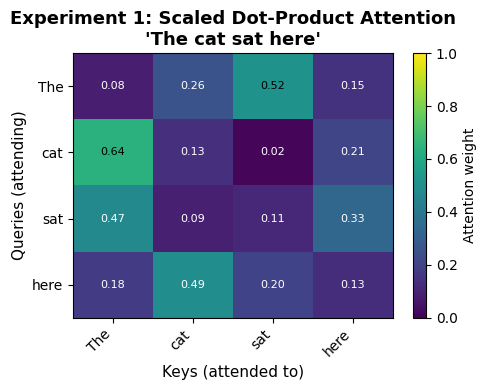

In [5]:
print("=" * 60)
print("🧪 Experiment 1: Scaled Dot-Product Attention from Scratch")
print("=" * 60)
print()

# Simulate a short sentence: ["The", "cat", "sat", "here"]
tokens = ["The", "cat", "sat", "here"]
seq_len = len(tokens)
d_k = 8   # key/query dimension
d_v = 8   # value dimension

np.random.seed(42)
Q = np.random.randn(seq_len, d_k)   # (4, 8)
K = np.random.randn(seq_len, d_k)   # (4, 8)
V = np.random.randn(seq_len, d_v)   # (4, 8)

print(f"Tokens:        {tokens}")
print(f"Sequence len:  {seq_len}")
print(f"Q/K dimension: {d_k}")
print(f"V dimension:   {d_v}")
print()

# Run attention
output, attention_weights = scaled_dot_product_attention(Q, K, V)

print("Attention weight matrix (rows=queries, cols=keys):")
print("  Each row sums to 1.0 (softmax output)")
print()
print(f"{'':6}", end="")
for t in tokens:
    print(f"{t:>8}", end="")
print()
for i, tok in enumerate(tokens):
    print(f"{tok:<6}", end="")
    for j in range(seq_len):
        print(f"{attention_weights[i,j]:>8.3f}", end="")
    print()

print()
print("Row sums (should all be ~1.0):", np.round(attention_weights.sum(axis=1), 4))

# Visualise
save_path = os.path.join(heatmap_dir, 'exp1_basic_attention.png')
plot_attention_heatmap(
    attention_weights, tokens,
    title="Experiment 1: Scaled Dot-Product Attention\n'The cat sat here'",
    save_path=save_path
)

### 🎯 TODO 1: Modify the Query Vector

**Task:** Change the query vector for the token `"cat"` (index 1) and observe how the attention distribution shifts.

The idea: different Q vectors represent different "things the model is looking for".

Modified attention weights for 'cat' query (row 1):
  Original: [0.641 0.133 0.017 0.209]
  Modified: [0.25 0.25 0.25 0.25]

✓ Heatmap saved to: ../outputs/attention_heatmaps/exp1_modified_query.png


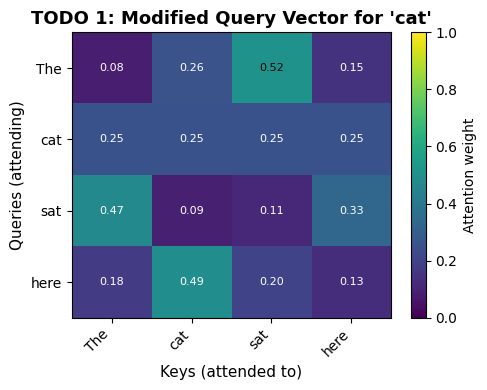

Your observation:

[YOUR OBSERVATION HERE]

Describe:
- What Q vector change did you make?
- How did the attention distribution for 'cat' change?
- What does this tell you about how Q vectors control what a token attends to?



In [6]:
# TODO 1: Experiment with different Q vectors

# Start with the original Q matrix
Q_modified = Q.copy()

# Modify the query for "cat" (row index 1)
# Try: make it all zeros, or a large positive value, or equal to K[2] (key of "sat")
Q_modified[1] = np.zeros(d_k)   # ← Change this! Try K[2], or np.ones(d_k)*5, etc.

_, attn_modified = scaled_dot_product_attention(Q_modified, K, V)

print("=" * 60)
print("Modified attention weights for 'cat' query (row 1):")
print("  Original:", np.round(attention_weights[1], 3))
print("  Modified:", np.round(attn_modified[1], 3))
print()

save_path_mod = os.path.join(heatmap_dir, 'exp1_modified_query.png')
plot_attention_heatmap(
    attn_modified, tokens,
    title="TODO 1: Modified Query Vector for 'cat'",
    save_path=save_path_mod
)

# TODO: Write your observation below
todo1_reflection = """
[YOUR OBSERVATION HERE]

Describe:
- What Q vector change did you make?
- How did the attention distribution for 'cat' change?
- What does this tell you about how Q vectors control what a token attends to?
"""

print("Your observation:")
print(todo1_reflection)

---

## Part 2: Multi-Head Attention with BertViz

A single attention head captures one type of relationship. **Multi-head attention** runs several heads in parallel — one might capture grammatical dependencies, another semantic similarity, another positional proximity.

We'll use **BertViz** to interactively visualise attention heads in a real BERT model.

In [7]:
print("=" * 60)
print("🧪 Experiment 2: Multi-Head Attention with BertViz")
print("=" * 60)
print()

demo_sentence = "The quick brown fox jumps over the lazy dog"
print(f"Sentence: \"{demo_sentence}\"")
print()
print("Loading BERT model and computing attention...")
print("(First run downloads ~440MB — subsequent runs use cache)")
print()

multi_head_demo(
    sentence=demo_sentence,
    model_name="bert-base-uncased",
    save_dir=heatmap_dir
)

print()
print("💡 In the BertViz head view, each colour represents a different attention head.")
print("   Notice how different heads focus on different word relationships.")

🧪 Experiment 2: Multi-Head Attention with BertViz

Sentence: "The quick brown fox jumps over the lazy dog"

Loading BERT model and computing attention...
(First run downloads ~440MB — subsequent runs use cache)

Loading bert-base-uncased...
✓ BertViz available — rendering interactive view


<IPython.core.display.Javascript object>


💡 In the BertViz head view, each colour represents a different attention head.
   Notice how different heads focus on different word relationships.


### 🎯 TODO 2: Your Own Sentence

In [8]:
# TODO 2: Provide your own sentence and analyse what you see

# Use a sentence relevant to your project domain, or any sentence you find interesting
my_sentence = "The neural network learned to classify images accurately."  # ← Change this!

print(f"My sentence: \"{my_sentence}\"")
print()

multi_head_demo(
    sentence=my_sentence,
    model_name="bert-base-uncased",
    save_dir=heatmap_dir
)

# TODO: Write your observation
todo2_reflection = """
[YOUR OBSERVATION HERE]

Describe:
- Which words appear to have strong attention connections?
- Can you identify any heads that seem to focus on syntax vs. meaning?
- Does [CLS] (the first token) attend broadly or narrowly?
"""

print("Your observation:")
print(todo2_reflection)

My sentence: "The neural network learned to classify images accurately."

Loading bert-base-uncased...
✓ BertViz available — rendering interactive view


<IPython.core.display.Javascript object>

Your observation:

[YOUR OBSERVATION HERE]

Describe:
- Which words appear to have strong attention connections?
- Can you identify any heads that seem to focus on syntax vs. meaning?
- Does [CLS] (the first token) attend broadly or narrowly?



---

## Part 3: Positional Encoding

Transformers process all tokens **in parallel** — unlike RNNs, they have no built-in notion of order.
Positional encoding adds a unique signal to each position so the model can distinguish token order.

The original Transformer uses sinusoidal encoding:
$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d}}\right) \qquad PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d}}\right)$$

🧪 Experiment 3: Sinusoidal Positional Encoding

Positional encoding shape: (50, 64)  (50 positions × 64 dims)

✓ Saved: ../outputs/attention_heatmaps/exp3_positional_encoding.png


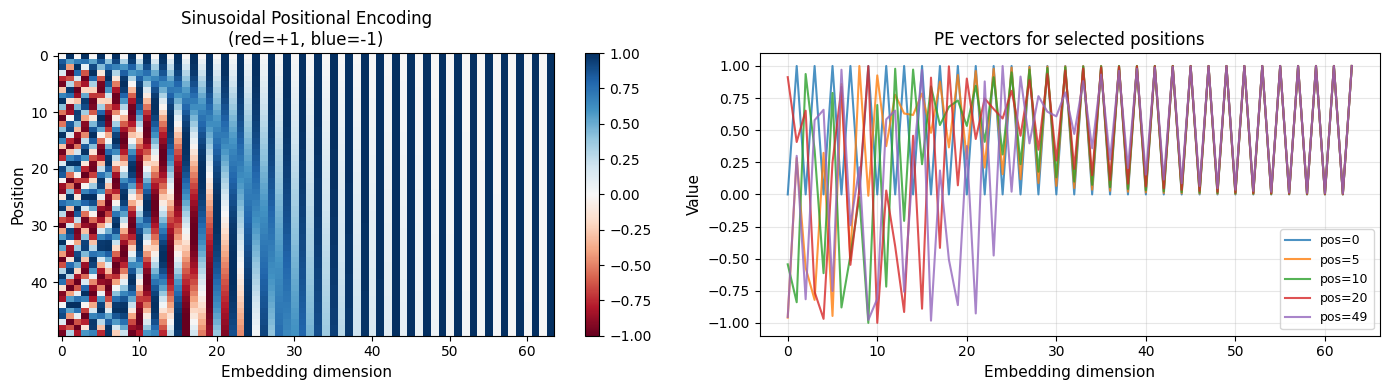


🔑 Key insight: Every position has a unique fingerprint across all dimensions.
   The model can learn to decode position from these signals.


In [9]:
print("=" * 60)
print("🧪 Experiment 3: Sinusoidal Positional Encoding")
print("=" * 60)
print()

def sinusoidal_pe(max_len: int, d_model: int) -> np.ndarray:
    """Compute sinusoidal positional encoding. Returns (max_len, d_model)."""
    pe  = np.zeros((max_len, d_model))
    pos = np.arange(max_len)[:, None]          # (max_len, 1)
    dim = np.arange(0, d_model, 2)             # even dimensions
    div = np.power(10000, dim / d_model)        # (d_model/2,)
    pe[:, 0::2] = np.sin(pos / div)
    pe[:, 1::2] = np.cos(pos / div)
    return pe

max_len = 50
d_model = 64
pe = sinusoidal_pe(max_len, d_model)

print(f"Positional encoding shape: {pe.shape}  ({max_len} positions × {d_model} dims)")
print()

# Plot: heatmap of PE matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: full PE heatmap
im = axes[0].imshow(pe, cmap='RdBu', aspect='auto', vmin=-1, vmax=1)
axes[0].set_xlabel('Embedding dimension', fontsize=11)
axes[0].set_ylabel('Position', fontsize=11)
axes[0].set_title('Sinusoidal Positional Encoding\n(red=+1, blue=-1)', fontsize=12)
plt.colorbar(im, ax=axes[0])

# Right: PE curves for a few positions
for pos in [0, 5, 10, 20, 49]:
    axes[1].plot(pe[pos], label=f'pos={pos}', alpha=0.8)
axes[1].set_xlabel('Embedding dimension', fontsize=11)
axes[1].set_ylabel('Value', fontsize=11)
axes[1].set_title('PE vectors for selected positions', fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
pe_path = os.path.join(heatmap_dir, 'exp3_positional_encoding.png')
plt.savefig(pe_path, dpi=150, bbox_inches='tight')
print(f"✓ Saved: {pe_path}")
plt.show()

print()
print("🔑 Key insight: Every position has a unique fingerprint across all dimensions.")
print("   The model can learn to decode position from these signals.")

---

## Part 4: MiniTransformerBlock (PyTorch)

Let's wire everything together into a single Transformer encoder block:

```
Input → Multi-Head Self-Attention → Add & LayerNorm → FeedForward → Add & LayerNorm → Output
```

This is the repeating unit stacked 12× in BERT-base, 96× in GPT-3.

In [10]:
print("=" * 60)
print("🧪 Experiment 4: MiniTransformerBlock Forward Pass")
print("=" * 60)
print()

try:
    import torch

    # Create the block
    d_model   = 64
    num_heads = 4
    d_ff      = 256

    block = MiniTransformerBlock(d_model=d_model, num_heads=num_heads, d_ff=d_ff)
    block.eval()

    print(f"MiniTransformerBlock config:")
    print(f"  d_model   = {d_model}  (embedding dimension)")
    print(f"  num_heads = {num_heads}  (attention heads)")
    print(f"  d_ff      = {d_ff}  (feed-forward inner dim)")
    print(f"  d_head    = {d_model // num_heads}  (per-head dimension)")
    print(f"  Parameters: {block.count_parameters():,}")
    print()

    # Dummy input: batch=2, seq_len=10, d_model=64
    batch_size = 2
    seq_len    = 10
    x = torch.randn(batch_size, seq_len, d_model)

    print(f"Input  shape: {tuple(x.shape)}  (batch, seq_len, d_model)")

    with torch.no_grad():
        output = block(x)

    print(f"Output shape: {tuple(output.shape)}  ← same shape as input! ✅")
    print()
    print("✅ Forward pass successful")
    print()
    print("🔑 Key insight: The Transformer block is shape-preserving.")
    print("   Stack N of these → N-layer Transformer.")
    print("   Output has the same shape as input — perfect for residual connections.")

except ImportError:
    print("⚠️  PyTorch not installed — skipping this experiment")
    print("   Install: pip install torch")

🧪 Experiment 4: MiniTransformerBlock Forward Pass

MiniTransformerBlock config:
  d_model   = 64  (embedding dimension)
  num_heads = 4  (attention heads)
  d_ff      = 256  (feed-forward inner dim)
  d_head    = 16  (per-head dimension)
  Parameters: 49,728

Input  shape: (2, 10, 64)  (batch, seq_len, d_model)
Output shape: (2, 10, 64)  ← same shape as input! ✅

✅ Forward pass successful

🔑 Key insight: The Transformer block is shape-preserving.
   Stack N of these → N-layer Transformer.
   Output has the same shape as input — perfect for residual connections.


---

## Part 5: Ask Claude to Explain Its Own Architecture

Now let's use what we've built to compare *our* implementation against Claude's explanation of how it works.

In [11]:
print("=" * 60)
print("🧪 Experiment 5: Ask Claude About Its Architecture")
print("=" * 60)
print()

prompt = (
    "You are a Transformer-based language model. "
    "Explain in exactly 5 bullet points what happens internally when you process "
    "the sentence 'The cat sat on the mat'. "
    "Focus on: tokenization → embedding → attention → output. "
    "Be technically accurate but concise."
)

start = time.time()
response = client.generate(prompt=prompt, max_tokens=600, temperature=0.5)
elapsed = time.time() - start

if "error" not in response:
    tracker.add_call(response)
    print(f"✅ Response in {elapsed:.1f}s")
    print(format_response(response, verbose=True))
else:
    print(f"❌ Error: {response['error']}")

🧪 Experiment 5: Ask Claude About Its Architecture

✅ Response in 10.3s
Model: claude-sonnet-4-6
Tokens: 62 in, 392 out
Stop reason: end_turn
# Internal Processing: 'The cat sat on the mat'

---

- **Tokenization:** The sentence is split into discrete tokens — likely `["The", "cat", "sat", "on", "the", "mat", "."]` — each mapped to a unique integer ID from the learned vocabulary (e.g., BPE or WordPiece), converting raw text into a numerical sequence the model can ingest.

- **Embedding + Positional Encoding:** Each token ID is looked up in a learned embedding matrix, producing a dense vector (e.g., 768 dimensions). A positional encoding vector is **added** to each token embedding, injecting sequential order information since the architecture itself has no inherent notion of position.

- **Multi-Head Self-Attention:** Each token computes **Query, Key, and Value** vectors via learned weight matrices. Dot products between Q and K vectors produce attention scores (scaled by √d_k, then softm

### 🎯 TODO 3: Ask Claude About Your Confusing Component

Pick the part of Transformer architecture you found most confusing or interesting and ask Claude to explain it.

In [12]:
# TODO 3: Ask Claude about a component you want to understand better

my_question = """
Why does Layer Normalization in Transformers normalize across the feature dimension
(not the batch dimension like BatchNorm)?  What goes wrong if you use BatchNorm instead?
"""  # ← Change this to your own question!

print("=" * 60)
print("🎯 TODO 3: My Architecture Question")
print("=" * 60)
print(f"Question: {my_question.strip()}")
print()

start = time.time()
response_todo3 = client.generate(
    prompt=my_question,
    system="You are an expert ML educator. Give a clear, technically accurate answer in under 200 words.",
    max_tokens=400,
    temperature=0.3,
)
elapsed = time.time() - start

if "error" not in response_todo3:
    tracker.add_call(response_todo3)
    print(format_response(response_todo3, verbose=True))
else:
    print(f"❌ Error: {response_todo3['error']}")

# TODO: Write what you learned
todo3_reflection = """
[YOUR REFLECTION HERE]

- What did you ask about?
- What did you learn from the answer?
- How does this connect to what we implemented in experiments 1–4?
"""

print()
print("My reflection:")
print(todo3_reflection)

🎯 TODO 3: My Architecture Question
Question: Why does Layer Normalization in Transformers normalize across the feature dimension
(not the batch dimension like BatchNorm)?  What goes wrong if you use BatchNorm instead?

Model: claude-sonnet-4-6
Tokens: 69 in, 322 out
Stop reason: end_turn
## Why Layer Norm Normalizes Across Features

**Layer Norm** computes mean and variance across the **embedding/feature dimension** for each token independently:
- Each token gets its own statistics → no dependency between sequence positions or batch items

**BatchNorm** computes statistics across the **batch dimension** for each feature:
- Requires aggregating across all samples in a mini-batch

---

## What Goes Wrong with BatchNorm in Transformers

**1. Variable sequence lengths**
Padding tokens pollute batch statistics — you'd be normalizing real tokens using statistics contaminated by padding.

**2. Small or size-1 batches**
BatchNorm's statistics become noisy or undefined. Inference with batch siz

## Summary & Reflection

In [13]:
# Combine all reflections
full_reflection = f"""
### Experiment 1 — Scaled Dot-Product Attention

Q/K/V dimensions: {d_k}/{d_k}/{d_v}
Tokens: {tokens}

**What I observed when modifying the Q vector:**
{todo1_reflection.strip()}

---

### Experiment 2 — Multi-Head Attention (BertViz)

My sentence: "{my_sentence}"

**What I observed in the attention heads:**
{todo2_reflection.strip()}

---

### TODO 3 — Architecture Question

My question: {my_question.strip()}

**What I learned:**
{todo3_reflection.strip()}
"""

reflection_file = append_to_reflection(
    notebook="02",
    section_title="Transformer Architecture Insights",
    reflection_content=full_reflection,
    output_dir=os.path.join('..', 'outputs')
)

print(f"✅ Reflection saved: {reflection_file}")
print()

tracker.report()

✅ Reflection saved: ../outputs/homework_reflection.md

💰 API COST REPORT
Total API calls:     4
Total input tokens:  262
Total output tokens: 1,491
Total cost:          $0.0232

Last 4 calls:
  1. [22:43:09] sonnet — 62in/449out — $0.0069
  2. [22:45:43] sonnet — 69in/328out — $0.0051
  3. [22:50:59] sonnet — 62in/392out — $0.0061
  4. [22:51:07] sonnet — 69in/322out — $0.0050


## ✅ Notebook 02 Complete!

**What you accomplished:**
- ✅ Implemented scaled dot-product attention from scratch in NumPy
- ✅ Visualised multi-head attention with BertViz (or matplotlib fallback)
- ✅ Plotted sinusoidal positional encoding and understood why it works
- ✅ Ran a MiniTransformerBlock forward pass in PyTorch
- ✅ Asked Claude to explain its own architecture and compared to your implementation
- ✅ Saved attention heatmaps to `outputs/attention_heatmaps/`

**Key concepts:**
- Attention = weighted average of values, weights determined by query-key similarity
- Multi-head = multiple attention patterns running in parallel
- Positional encoding = unique signal added to each position's embedding
- Residual + LayerNorm = enables deep stacking without gradient vanishing

**Next:** Open **Notebook 03: Tokenization** 🔤